Step 1: Import Libraries

In [5]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

Step 2: Download Live Stock Data

In [6]:
data=yf.download('AAPl',start='2023-01-01',end='2026-03-16')

#preview data
data.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 801 entries, 2023-01-03 to 2026-03-13
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   801 non-null    float64
 1   (High, AAPL)    801 non-null    float64
 2   (Low, AAPL)     801 non-null    float64
 3   (Open, AAPL)    801 non-null    float64
 4   (Volume, AAPL)  801 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 37.5 KB


Step 3: Clean & Prep the Data

In [7]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096024,128.834003,122.210227,128.223793,112117500
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700
2023-01-06,127.574219,128.233642,122.918876,124.021202,87754700
2023-01-09,128.095825,131.304382,127.839934,128.410782,70790800


In [8]:
#Use only the closing prices
data=data[['Close']].dropna()

#Add a new column for "Day" since the start day
data['Days']=(data.index - data.index[0]).days

Step 4: Plot the Data

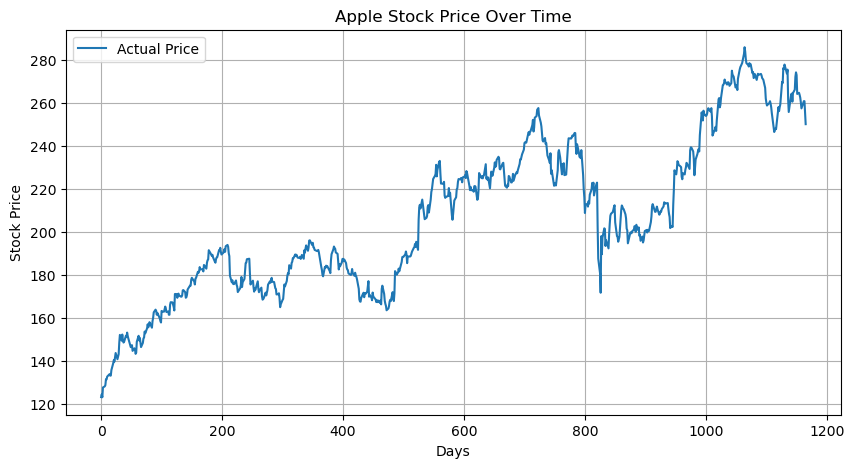

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data['Days'],data['Close'],label='Actual Price')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Apple Stock Price Over Time')
plt.legend()
plt.grid(True)
plt.show()

Step 5: Train a simple Linear Regression Model

In [10]:
#Prepare features and target
X=data[['Days']]
y=data['Close']

#Create and fit the model
model=LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Step 6: Predict the Next 30 Days

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


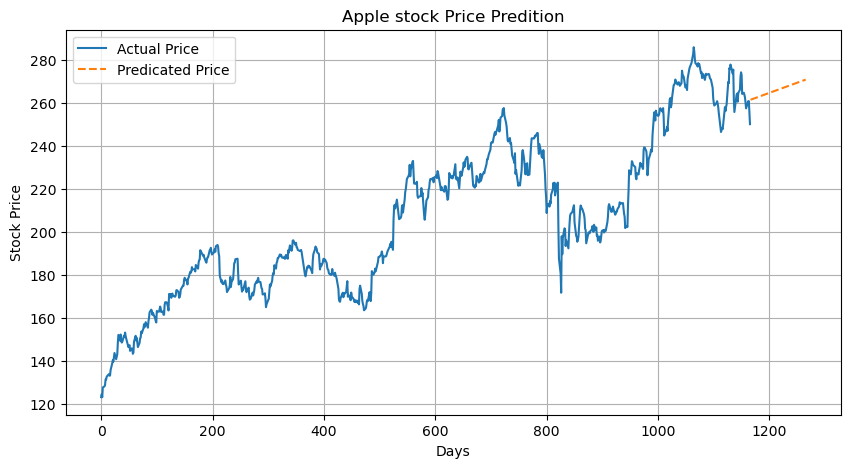

In [12]:
#Predict next 30 days
future_days = pd.DataFrame({'Days':range(data['Days'].max()+1,data['Days'].max()+31)})
future_prices = model.predict(future_days)

#Plot predicition
plt.figure(figsize=(10,5))
plt.plot(data['Days'],data['Close'],label='Actual Price')
plt.plot(future_days,future_prices,label='Predicated Price',linestyle='--')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Apple stock Price Predition')
plt.legend()
plt.grid(True)
plt.show()